In [14]:
# =========================
# STAGE 2 CONFIG
# =========================

import numpy as np
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

# Parallelism
MAX_WORKERS = 24
CHUNKSIZE = 64

@dataclass(frozen=True)
class SimParams:
    T: float = 2.0
    dt: float = 1e-4
    discard: float = 0.2
    seed: int = 0

SIM = SimParams(T=2.0, dt=1e-4, discard=0.2, seed=0)
BETA_BAND = (13.0, 30.0)

# ===== Grid sizes (pick powers-of-two when possible) =====
# Suggested "big but manageable" for Stage 2:
# 64 x 64 x 16 x 2 = 131072 (2^17)
F_VALS = np.linspace(60, 180, 64)     # Hz
A_VALS = np.linspace(0.0, 1.5, 64)    # model units (stay in sensitive region)
PW_US  = np.linspace(50, 240, 16)     # microseconds
PW_VALS = PW_US * 1e-6                # seconds

# Contact Mode: 0=ring, 1=directional
MODE_NAMES = ["ring", "directional"]
M_VALS = np.array([0, 1], dtype=int)

# ===== Physics factors (Stage 2) =====
AREA_FACTOR      = np.array([1.0, 0.25])  # directional smaller area => higher charge density
IMPEDANCE_FACTOR = np.array([1.0, 2.0])   # directional higher impedance => higher energy draw
FOCUS_FACTOR     = np.array([1.0, 1.4])   # directional more effective at target (explicit assumption)

# Safety constraint proxy: charge density ~ (A * PW)/Area
QD_LIMIT = 0.60        # tighten/loosen if needed
INFEAS_COST = 1e6      # cost assigned to infeasible points (avoid them)

# Scalar objective parameters
PENALTY = 5.0          # penalty for exceeding knee energy budget

# Benchmark settings
BUDGET = 40
SEEDS  = 10

# Optional: Bayesian optimization, CMA-ES, QAOA
USE_BAYES_OPT = True
USE_CMA_ES = True
USE_QAOA = True

# Derived sizes
Nf, Na, Npw, Nm = len(F_VALS), len(A_VALS), len(PW_VALS), len(M_VALS)
N_TOTAL = Nf * Na * Npw * Nm
print("Grid size:", (Nf, Na, Npw, Nm), "=", N_TOTAL)


Grid size: (64, 64, 16, 2) = 131072


In [5]:
# =========================
# SIGNAL METRICS
# =========================

import numpy as np
from scipy.signal import welch

def beta_band_power(signal: np.ndarray, fs: float, band: Tuple[float, float] = (13.0, 30.0)) -> float:
    f, P = welch(signal, fs=fs, nperseg=min(len(signal), 8192))
    lo, hi = band
    mask = (f >= lo) & (f <= hi)
    return float(np.trapz(P[mask], f[mask]))

def estimate_peak_hz(signal: np.ndarray, fs: float) -> float:
    f, P = welch(signal, fs=fs, nperseg=min(len(signal), 8192))
    idx = np.argmax(P[1:]) + 1
    return float(f[idx])


In [6]:
# =========================
# STN–GPe SIMULATOR
# =========================

import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple

def tanh_act(x: float, gain: float) -> float:
    return float(np.tanh(gain * x))

@dataclass(frozen=True)
class STNGPePatient:
    tau_stn: float
    tau_gpe: float
    delay_stn_to_gpe: float
    delay_gpe_to_stn: float
    w_stn_to_gpe: float
    w_gpe_to_stn: float
    I_cort: float
    I_gpe_bias: float
    gain_stn: float
    gain_gpe: float
    noise_std: float = 0.0

@dataclass(frozen=True)
class DBSParams:
    f_hz: float
    A: float
    pw_s: float

# Main patient (from your search)
MAIN_PATIENT = STNGPePatient(
    tau_stn=0.009480108684355502,
    tau_gpe=0.01568342986890998,
    delay_stn_to_gpe=0.005856049933455449,
    delay_gpe_to_stn=0.004355096988711622,
    w_stn_to_gpe=0.8766085173129406,
    w_gpe_to_stn=0.8007248587605185,
    I_cort=0.21584549577209655,
    I_gpe_bias=0.0,
    gain_stn=2.418440027526686,
    gain_gpe=2.4195288944990088,
    noise_std=0.0
)

def simulate_stn_gpe(patient: STNGPePatient, dbs: Optional[DBSParams], sim: SimParams) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(sim.seed)
    n = int(sim.T / sim.dt)
    t = np.arange(n) * sim.dt

    stn = np.zeros(n, dtype=float)
    gpe = np.zeros(n, dtype=float)
    stn[0], gpe[0] = 0.1, 0.1

    d_sg = max(1, int(patient.delay_stn_to_gpe / sim.dt))
    d_gs = max(1, int(patient.delay_gpe_to_stn / sim.dt))

    if dbs is None or dbs.A == 0 or dbs.f_hz == 0 or dbs.pw_s == 0:
        f = 0.0; A = 0.0; pw = 0.0
    else:
        f = float(dbs.f_hz); A = float(dbs.A); pw = float(dbs.pw_s)

    period = 1.0 / f if f > 0 else None
    next_pulse = 0.0
    pulse_end = -1.0

    for k in range(n - 1):
        tt = t[k]

        Idbs = 0.0
        if f > 0:
            if tt >= next_pulse:
                pulse_end = next_pulse + pw
                next_pulse += period
            if tt < pulse_end:
                Idbs = A

        stn_del = stn[k - d_sg] if k >= d_sg else stn[0]
        gpe_del = gpe[k - d_gs] if k >= d_gs else gpe[0]

        ns = patient.noise_std * rng.standard_normal()
        ng = patient.noise_std * rng.standard_normal()

        inp_stn = patient.I_cort - patient.w_gpe_to_stn * gpe_del + Idbs + ns
        inp_gpe = patient.w_stn_to_gpe * stn_del + patient.I_gpe_bias + ng

        Fstn = tanh_act(inp_stn, patient.gain_stn)
        Fgpe = tanh_act(inp_gpe, patient.gain_gpe)

        dstn = (-stn[k] + Fstn) / patient.tau_stn
        dgpe = (-gpe[k] + Fgpe) / patient.tau_gpe

        stn[k + 1] = stn[k] + sim.dt * dstn
        gpe[k + 1] = gpe[k] + sim.dt * dgpe

    start = int(sim.discard / sim.dt)
    return t[start:], (stn - gpe)[start:]


In [7]:
# =========================
# 4D Indexing Helpers (fi, ai, pwi, mi) <-> flat
# =========================

def flat_index(fi:int, ai:int, pwi:int, mi:int) -> int:
    return (((fi * Na + ai) * Npw + pwi) * Nm + mi)

def unflat_index(flat:int) -> Tuple[int,int,int,int]:
    mi = flat % Nm
    flat //= Nm
    pwi = flat % Npw
    flat //= Npw
    ai = flat % Na
    flat //= Na
    fi = flat
    return fi, ai, pwi, mi


In [8]:
# =========================
# ORACLE BUILD (parallel)
# Outputs arrays of length N_TOTAL:
#   beta_ratio_flat, energy_flat, qd_flat, feasible_flat
# =========================

import multiprocessing as mp

def baseline_beta(patient: STNGPePatient, sim: SimParams) -> Tuple[float, float]:
    t, y = simulate_stn_gpe(patient, dbs=None, sim=sim)
    fs = 1.0 / (t[1] - t[0])
    b0 = beta_band_power(y, fs, BETA_BAND)
    return float(fs), float(b0)

FS, B0 = baseline_beta(MAIN_PATIENT, SIM)
t0, y0 = simulate_stn_gpe(MAIN_PATIENT, dbs=None, sim=SIM)
print("Baseline peak freq:", estimate_peak_hz(y0, FS))

F_MAX = float(F_VALS.max())
A_MAX = float(A_VALS.max()) if float(A_VALS.max()) > 0 else 1.0
PW_MAX = float(PW_VALS.max())

def charge_density_proxy(A: float, pw_s: float, mi: int) -> float:
    # QD ~ (A*PW)/Area, normalized to max ranges
    base = (A / A_MAX) * (pw_s / PW_MAX)
    return float(base / AREA_FACTOR[mi])

def energy_proxy(f_hz: float, A: float, pw_s: float, mi: int) -> float:
    # Energy ~ I^2 * Z * f * PW (normalized)
    base = (A / A_MAX)**2 * (f_hz / F_MAX) * (pw_s / PW_MAX)
    return float(base * IMPEDANCE_FACTOR[mi])

def worker_eval(task: Tuple[int,int,int,int]) -> Tuple[int, float, float, float, int]:
    fi, ai, pwi, mi = task
    f = float(F_VALS[fi])
    A = float(A_VALS[ai])
    pw = float(PW_VALS[pwi])

    qd = charge_density_proxy(A, pw, mi)
    feasible = 1 if (qd <= QD_LIMIT) else 0

    if feasible == 0:
        return flat_index(fi, ai, pwi, mi), float("inf"), float("inf"), float(qd), 0

    # Directional "focus" benefit: more effective at target (assumption)
    A_eff = float(A * FOCUS_FACTOR[mi])

    dbs = DBSParams(f_hz=f, A=A_eff, pw_s=pw)
    t, y = simulate_stn_gpe(MAIN_PATIENT, dbs=dbs, sim=SIM)

    beta = beta_band_power(y, FS, BETA_BAND)
    beta_ratio = float(beta / (B0 + 1e-12))
    e = energy_proxy(f, A, pw, mi)

    return flat_index(fi, ai, pwi, mi), beta_ratio, e, float(qd), 1

def build_oracle_parallel():
    tasks = [(fi, ai, pwi, mi)
             for fi in range(Nf) for ai in range(Na) for pwi in range(Npw) for mi in range(Nm)]

    workers = min(MAX_WORKERS, mp.cpu_count())
    print(f"Building oracle N={len(tasks)} with {workers} workers...")

    try:
        ctx = mp.get_context("fork")
    except ValueError:
        ctx = mp.get_context("spawn")

    beta_ratio = np.full(N_TOTAL, float("inf"), dtype=float)
    energy = np.full(N_TOTAL, float("inf"), dtype=float)
    qd = np.zeros(N_TOTAL, dtype=float)
    feasible = np.zeros(N_TOTAL, dtype=np.int8)

    t0 = time.time()
    with ctx.Pool(processes=workers) as pool:
        for flat, br, e, qd_val, ok in pool.imap_unordered(worker_eval, tasks, chunksize=CHUNKSIZE):
            beta_ratio[flat] = br
            energy[flat] = e
            qd[flat] = qd_val
            feasible[flat] = ok
    t1 = time.time()
    print(f"Oracle built in {t1-t0:.2f}s")

    return beta_ratio, energy, qd, feasible

beta_ratio_flat, energy_flat, qd_flat, feasible_flat = build_oracle_parallel()

feas = feasible_flat == 1
print("Feasible points:", int(feas.sum()), "/", N_TOTAL)
print("beta_ratio range (feasible):", float(beta_ratio_flat[feas].min()), "to", float(beta_ratio_flat[feas].max()))
print("energy range (feasible):", float(energy_flat[feas].min()), "to", float(energy_flat[feas].max()))


Baseline peak freq: 19.53125000000215
Building oracle N=131072 with 24 workers...
Oracle built in 319.05s
Feasible points: 77504 / 131072
beta_ratio range (feasible): 0.7590422931983027 to 1.0001569216698758
energy range (feasible): 0.0 to 0.5777777777777778


In [9]:
# =========================
# PARETO + KNEE (feasible only)
# =========================

def pareto_front_fast(beta: np.ndarray, energy: np.ndarray) -> np.ndarray:
    order = np.argsort(beta)
    keep = []
    best_e = float("inf")
    for idx in order:
        e = float(energy[idx])
        if e < best_e:
            keep.append(int(idx))
            best_e = e
    return np.array(keep, dtype=int)

def choose_knee(beta_front: np.ndarray, energy_front: np.ndarray) -> int:
    b_min, b_max = float(beta_front.min()), float(beta_front.max())
    e_min, e_max = float(energy_front.min()), float(energy_front.max())
    bn = (beta_front - b_min) / (b_max - b_min + 1e-12)
    en = (energy_front - e_min) / (e_max - e_min + 1e-12)
    dist = np.sqrt(bn**2 + en**2)
    return int(np.argmin(dist))

feas_idx = np.where(feasible_flat == 1)[0]
beta_feas = beta_ratio_flat[feas_idx]
energy_feas = energy_flat[feas_idx]

pareto_local = pareto_front_fast(beta_feas, energy_feas)
pareto_idx = feas_idx[pareto_local]

beta_p = beta_ratio_flat[pareto_idx]
energy_p = energy_flat[pareto_idx]
knee_local = choose_knee(beta_p, energy_p)
knee_flat = int(pareto_idx[knee_local])

kfi, kai, kpwi, kmi = unflat_index(knee_flat)

knee = {
    "mode": MODE_NAMES[kmi],
    "f_hz": float(F_VALS[kfi]),
    "A": float(A_VALS[kai]),
    "pw_us": float(PW_US[kpwi]),
    "beta_ratio": float(beta_ratio_flat[knee_flat]),
    "energy": float(energy_flat[knee_flat]),
    "qd": float(qd_flat[knee_flat]),
}
print("Pareto points:", len(pareto_idx))
print("Knee:", knee)


Pareto points: 98
Knee: {'mode': 'ring', 'f_hz': 159.04761904761904, 'A': 0.5, 'pw_us': 240.0, 'beta_ratio': 0.8228584997287205, 'energy': 0.09817754262198705, 'qd': 0.3333333333333333}


In [10]:
# =========================
# Scalar objective + ground truth (Stage 2)
# =========================

def scalar_cost(beta_ratio: np.ndarray, energy: np.ndarray, feasible: np.ndarray, E_max: float, penalty: float) -> np.ndarray:
    over = np.maximum(0.0, energy - E_max)
    cost = beta_ratio + penalty * over
    cost = np.where(feasible == 1, cost, INFEAS_COST)
    return cost

E_KNEE = float(knee["energy"])
cost_flat = scalar_cost(beta_ratio_flat, energy_flat, feasible_flat, E_max=E_KNEE, penalty=PENALTY)

best_flat = int(np.argmin(cost_flat))
bfi, bai, bpwi, bmi = unflat_index(best_flat)

ground_truth = {
    "E_knee": E_KNEE,
    "penalty": PENALTY,
    "cost_star": float(cost_flat[best_flat]),
    "best_setting": {
        "mode": MODE_NAMES[bmi],
        "f_hz": float(F_VALS[bfi]),
        "A": float(A_VALS[bai]),
        "pw_us": float(PW_US[bpwi]),
        "beta_ratio": float(beta_ratio_flat[best_flat]),
        "energy": float(energy_flat[best_flat]),
        "qd": float(qd_flat[best_flat]),
    }
}
print("GROUND TRUTH:", ground_truth)


GROUND TRUTH: {'E_knee': 0.09817754262198705, 'penalty': 5.0, 'cost_star': 0.8228584997287205, 'best_setting': {'mode': 'ring', 'f_hz': 159.04761904761904, 'A': 0.5, 'pw_us': 240.0, 'beta_ratio': 0.8228584997287205, 'energy': 0.09817754262198705, 'qd': 0.3333333333333333}}


In [11]:
# =========================
# Scoring helper
# =========================

def score_evals(evals: List[Tuple[int,int,int,int,float]], cost_star: float) -> Dict[str, float]:
    best = float("inf")
    for *_, c in evals:
        if c < best: best = c
    return {"final_best_cost": best, "final_regret": best - cost_star}

def run_method_summary(method_fn, name:str):
    finals, regrets = [], []
    for s in range(SEEDS):
        evals = method_fn(cost_flat, BUDGET, s)
        scored = score_evals(evals, ground_truth["cost_star"])
        finals.append(scored["final_best_cost"])
        regrets.append(scored["final_regret"])
    print(f"{name:20s} mean_final_cost={float(np.mean(finals)):.4f}  mean_regret={float(np.mean(regrets)):.4f}  std_cost={float(np.std(finals)):.4f}")


In [12]:
# =========================
# Random + GA (4D grid)
# =========================

def run_random(cost_flat: np.ndarray, budget:int, seed:int):
    rng = np.random.default_rng(seed)
    chosen = rng.choice(np.arange(N_TOTAL), size=min(budget, N_TOTAL), replace=False)
    evals = []
    for flat in chosen:
        fi, ai, pwi, mi = unflat_index(int(flat))
        evals.append((fi, ai, pwi, mi, float(cost_flat[int(flat)])))
    return evals

def run_ga(cost_flat: np.ndarray, budget:int, seed:int, pop_size:int=60):
    rng = np.random.default_rng(seed)
    bitlen = int(np.ceil(np.log2(N_TOTAL)))

    cache: Dict[int,float] = {}
    order: List[int] = []

    def cost_of(x:int) -> float:
        x = x % N_TOTAL
        if x not in cache:
            cache[x] = float(cost_flat[x])
            order.append(x)
        return cache[x]

    pop = [int(rng.integers(0, N_TOTAL)) for _ in range(pop_size)]
    for x in pop:
        if len(cache) >= budget: break
        cost_of(x)

    def tournament(k=3) -> int:
        cand = rng.choice(pop, size=k, replace=False)
        return int(min(cand, key=cost_of))

    def crossover(a:int, b:int):
        if rng.random() > 0.7:
            return a, b
        point = int(rng.integers(1, bitlen))
        mask = (1 << point) - 1
        a2 = (a & ~mask) | (b & mask)
        b2 = (b & ~mask) | (a & mask)
        return a2 % N_TOTAL, b2 % N_TOTAL

    def mutate(x:int, p:float):
        for bit in range(bitlen):
            if rng.random() < p:
                x ^= (1 << bit)
        return x % N_TOTAL

    p_mut = 1.0 / max(bitlen, 1)

    while len(cache) < budget:
        new_pop = []
        elite = sorted(pop, key=cost_of)[:2]
        new_pop.extend(elite)

        while len(new_pop) < pop_size:
            p1 = tournament()
            p2 = tournament()
            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1, p_mut)
            c2 = mutate(c2, p_mut)
            new_pop.extend([c1, c2])

        pop = new_pop[:pop_size]
        for x in pop:
            if len(cache) >= budget: break
            cost_of(x)

    evals = []
    for flat in order:
        fi, ai, pwi, mi = unflat_index(flat)
        evals.append((fi, ai, pwi, mi, float(cost_flat[flat])))
    return evals

run_method_summary(run_random, "random")
run_method_summary(run_ga, "ga")


random               mean_final_cost=0.8909  mean_regret=0.0681  std_cost=0.0220
ga                   mean_final_cost=0.8992  mean_regret=0.0763  std_cost=0.0247


In [32]:
def run_bo(cost_flat: np.ndarray, budget:int, seed:int, n_init:int=None, xi:float=0.01):
    """
    Bayesian Optimization (4D). Deterministic GP, EI acquisition.

    IMPORTANT FIX:
    - Ensure n_init < budget so BO actually runs sequential steps.
    """
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern, ConstantKernel
    from scipy.stats import norm
    import warnings
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    rng = np.random.default_rng(seed)

    if n_init is None:
        n_init = max(8, budget // 4)   # e.g., budget=20 -> 8 init points
    n_init = min(n_init, budget - 1)   # must be < budget
    if n_init < 2:
        n_init = 2

    # Candidate set in [0,1]^4 : (fi, ai, pwi, mi)
    X_all = []
    y_all = []
    idx_all = []
    for fi in range(Nf):
        for ai in range(Na):
            for pwi in range(Npw):
                for mi in range(Nm):
                    X_all.append([fi/(Nf-1), ai/(Na-1), pwi/(Npw-1), mi/(Nm-1)])
                    idx_all.append((fi, ai, pwi, mi))
                    y_all.append(float(cost_flat[flat_index(fi,ai,pwi,mi)]))

    X_all = np.array(X_all, dtype=float)
    y_all = np.array(y_all, dtype=float)

    remaining = np.arange(len(idx_all))
    rng.shuffle(remaining)

    obs_idx = list(remaining[:n_init])
    remaining = remaining[n_init:]

    X_obs = X_all[obs_idx].copy()
    y_obs = y_all[obs_idx].copy()
    evals = [(idx_all[i][0], idx_all[i][1], idx_all[i][2], idx_all[i][3], float(y_all[i])) for i in obs_idx]

    def EI(mu, sigma, best):
        sigma = np.maximum(sigma, 1e-12)
        imp = best - mu - xi
        Z = imp / sigma
        return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

    while len(evals) < budget and len(remaining) > 0:
        kernel = ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3)) * Matern(nu=2.5)
        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=1e-10,
            normalize_y=True,
            random_state=seed,
            n_restarts_optimizer=2
        )
        gp.fit(X_obs, y_obs)

        X_rem = X_all[remaining]
        mu, std = gp.predict(X_rem, return_std=True)
        best = float(np.min(y_obs))
        ei = EI(mu, std, best)

        pick_local = int(np.argmax(ei))
        pick = int(remaining[pick_local])
        remaining = np.delete(remaining, pick_local)

        X_obs = np.vstack([X_obs, X_all[pick]])
        y_obs = np.append(y_obs, y_all[pick])

        fi, ai, pwi, mi = idx_all[pick]
        evals.append((fi, ai, pwi, mi, float(y_all[pick])))

    return evals


In [16]:
# =========================
# CMA-ES (4D continuous -> rounded to grid)
# =========================

def run_cma_es(cost_flat: np.ndarray, budget:int, seed:int, sigma0:float=0.35, popsize:int=18):
    import cma

    rng = np.random.default_rng(seed)

    cache = {}
    evals = []

    def x_to_idx(x):
        x = np.clip(x, 0.0, 1.0)
        fi = int(round(x[0] * (Nf-1)))
        ai = int(round(x[1] * (Na-1)))
        pwi = int(round(x[2] * (Npw-1)))
        mi = int(round(x[3] * (Nm-1)))  # mode
        return fi, ai, pwi, mi

    def evaluate_x(x):
        fi, ai, pwi, mi = x_to_idx(x)
        flat = flat_index(fi, ai, pwi, mi)
        if flat not in cache and len(cache) < budget:
            cache[flat] = float(cost_flat[flat])
            evals.append((fi, ai, pwi, mi, float(cost_flat[flat])))
        return float(cost_flat[flat])

    x0 = [0.5, 0.5, 0.5, 0.0]  # start near ring mode
    es = cma.CMAEvolutionStrategy(
        x0, sigma0,
        {"seed": seed, "popsize": popsize, "bounds": [0.0, 1.0], "verbose": -9}
    )

    while not es.stop() and len(cache) < budget:
        X = es.ask()
        y = [evaluate_x(x) for x in X]
        es.tell(X, y)

    return evals

if USE_CMA_ES:
    run_method_summary(run_cma_es, "cma_es")
else:
    print("USE_CMA_ES=False (skipping CMA-ES).")


cma_es               mean_final_cost=0.8840  mean_regret=0.0611  std_cost=0.0214


In [23]:
# =========================
# Surrogate -> QUBO -> Exact solve (classical)
# =========================

def run_surrogate_exact(cost_flat: np.ndarray, budget:int, seed:int, n_init: int = None, ridge:float=1e-3):
    rng = np.random.default_rng(seed)
    N = cost_flat.size
    bitlen = int(np.ceil(np.log2(N)))

    if n_init is None:
        n_init = max(10, budget // 4)
    n_init = min(n_init, budget - 1)

    def flat_to_bits(flat:int) -> np.ndarray:
        return np.array([(flat >> (bitlen-1-i)) & 1 for i in range(bitlen)], dtype=float)

    def quad_design(B: np.ndarray) -> np.ndarray:
        m, n = B.shape
        cols = 1 + n + (n*(n-1))//2
        Phi = np.zeros((m, cols))
        Phi[:,0] = 1.0
        Phi[:,1:1+n] = B
        col = 1+n
        for i in range(n):
            for j in range(i+1, n):
                Phi[:,col] = B[:,i]*B[:,j]
                col += 1
        return Phi

    evaluated = set()
    evals: List[Tuple[int,int,int,int,float]] = []

    init = rng.choice(np.arange(N), size=n_init, replace=False)
    for flat in init:
        evaluated.add(int(flat))
        fi, ai, pwi, mi = unflat_index(int(flat))
        evals.append((fi, ai, pwi, mi, float(cost_flat[int(flat)])))

    while len(evals) < budget:
        flats = [flat_index(fi, ai, pwi, mi) for fi, ai, pwi, mi, _ in evals]
        Bmat = np.vstack([flat_to_bits(int(f)) for f in flats])
        y = np.array([c for *_, c in evals], dtype=float)

        Phi = quad_design(Bmat)
        I = np.eye(Phi.shape[1])
        coef = np.linalg.solve(Phi.T @ Phi + ridge * I, Phi.T @ y)

        # pick best predicted among a random candidate subset (speed for large N)
        # you can increase cand_pool for better selection
        cand_pool = 5000 if N > 50000 else N
        candidates = rng.choice(np.arange(N), size=min(cand_pool, N), replace=False)

        best_pred = float("inf")
        best_flat = None
        for flat in candidates:
            if int(flat) in evaluated:
                continue
            b = flat_to_bits(int(flat))
            pred = coef[0] + np.dot(coef[1:1+bitlen], b)
            col = 1+bitlen
            for i in range(bitlen):
                for j in range(i+1, bitlen):
                    pred += coef[col] * b[i]*b[j]
                    col += 1
            if pred < best_pred:
                best_pred = float(pred)
                best_flat = int(flat)

        if best_flat is None:
            break

        evaluated.add(best_flat)
        fi, ai, pwi, mi = unflat_index(best_flat)
        evals.append((fi, ai, pwi, mi, float(cost_flat[best_flat])))

    return evals

run_method_summary(run_surrogate_exact, "surrogate_exact")


surrogate_exact      mean_final_cost=0.9193  mean_regret=0.0964  std_cost=0.0223


In [30]:
def run_surrogate_qaoa(
    cost_flat: np.ndarray,
    budget: int,
    seed: int,
    p_layers: int = 1,
    shots: int = 256,
    maxiter: int = 25,
    ridge: float = 1e-3,
    max_pairs: int = 200,
    cand_pool: int = 8000,
    infeas_threshold: float = 1e5,
    verbose: bool = False,
):
    """
    Stage 2: Surrogate -> QUBO -> QAOA (SamplerV2, counts-based)

    Fixes:
    - n_init < budget so loop runs
    - init samples from feasible points
    - fit surrogate only on feasible evals
    - guided fallback (best predicted among candidate pool), not random fallback
    - SamplerV2 output parsed via get_counts() (NO quasi_dists)

    Requires:
      pip install qiskit qiskit-aer
    """
    import numpy as np
    from scipy.optimize import minimize
    from qiskit import QuantumCircuit
    from qiskit_aer.primitives import SamplerV2

    rng = np.random.default_rng(seed)
    N = int(cost_flat.size)
    bitlen = int(np.ceil(np.log2(N)))  # e.g., 17 for 131072

    # Ensure we actually do guided iterations
    if budget < 10:
        raise ValueError("budget too small; use at least 10.")
    n_init = max(10, budget // 4)
    n_init = min(n_init, budget - 1)

    # Feasible indices (avoid infeasible huge costs)
    feasible_idx = np.where(cost_flat < infeas_threshold)[0]
    if len(feasible_idx) == 0:
        feasible_idx = np.arange(N)

    def flat_to_bits(flat: int) -> np.ndarray:
        # MSB -> LSB
        return np.array([(flat >> (bitlen - 1 - i)) & 1 for i in range(bitlen)], dtype=float)

    def quad_design(B: np.ndarray) -> np.ndarray:
        # [1 | x_i | x_i x_j]
        m, n = B.shape
        cols = 1 + n + (n * (n - 1)) // 2
        Phi = np.zeros((m, cols), dtype=float)
        Phi[:, 0] = 1.0
        Phi[:, 1 : 1 + n] = B
        col = 1 + n
        for i in range(n):
            for j in range(i + 1, n):
                Phi[:, col] = B[:, i] * B[:, j]
                col += 1
        return Phi

    def fit_surrogate(evals_fit):
        flats = [flat_index(fi, ai, pwi, mi) for fi, ai, pwi, mi, _ in evals_fit]
        Bmat = np.vstack([flat_to_bits(int(f)) for f in flats])
        y = np.array([c for *_, c in evals_fit], dtype=float)

        Phi = quad_design(Bmat)
        I = np.eye(Phi.shape[1], dtype=float)
        theta = np.linalg.solve(Phi.T @ Phi + ridge * I, Phi.T @ y)

        b0 = float(theta[0])
        b_lin = theta[1 : 1 + bitlen].copy()

        b_pair = np.zeros((bitlen, bitlen), dtype=float)
        col = 1 + bitlen
        for i in range(bitlen):
            for j in range(i + 1, bitlen):
                b_pair[i, j] = float(theta[col])
                col += 1
        return b0, b_lin, b_pair

    def sparsify_pairs(b_pair: np.ndarray):
        pairs = []
        for i in range(bitlen):
            for j in range(i + 1, bitlen):
                w = float(b_pair[i, j])
                if w != 0.0:
                    pairs.append((i, j, w))
        pairs.sort(key=lambda x: abs(x[2]), reverse=True)
        return pairs[:max_pairs]

    def surrogate_value(bits: np.ndarray, b0, b_lin, b_pair) -> float:
        val = b0 + float(np.dot(b_lin, bits))
        for i in range(bitlen):
            for j in range(i + 1, bitlen):
                val += float(b_pair[i, j] * bits[i] * bits[j])
        return float(val)

    def build_qaoa(gammas, betas, b_lin, pairs):
        qc = QuantumCircuit(bitlen)
        qc.h(range(bitlen))

        for layer in range(p_layers):
            g = float(gammas[layer])
            b = float(betas[layer])

            # linear terms
            for i in range(bitlen):
                w = float(b_lin[i])
                if w != 0.0:
                    qc.rz(2 * g * w, i)

            # pair terms
            for i, j, w in pairs:
                qc.rzz(2 * g * w, i, j)

            # mixer
            for i in range(bitlen):
                qc.rx(2 * b, i)

        qc.measure_all()
        return qc

    # ---- SamplerV2 counts → probability dict helper ----
    sampler = SamplerV2()

    def sampler_probs(qc: QuantumCircuit, shots: int) -> Dict[str, float]:
        """
        Return dict: bitstring -> probability
        for SamplerV2 result.
        """
        result = sampler.run([qc], shots=shots).result()
        pub = result[0]  # PubResult
        data = pub.data

        # Try common classical register names first
        counts = None
        for name in ["meas", "cr", "c", "m"]:
            if hasattr(data, name):
                obj = getattr(data, name)
                if hasattr(obj, "get_counts"):
                    counts = obj.get_counts()
                    break

        # Fallback: find any attribute with get_counts()
        if counts is None:
            for name in dir(data):
                if name.startswith("_"):
                    continue
                obj = getattr(data, name)
                if hasattr(obj, "get_counts"):
                    counts = obj.get_counts()
                    break

        if counts is None:
            raise RuntimeError("Could not find counts in SamplerV2 result. Try naming a classical register explicitly.")

        # Convert counts to probabilities
        probs = {}
        total = float(shots)
        for bitstr, ct in counts.items():
            # some backends include spaces, e.g. "0 1 1"
            bs = str(bitstr).replace(" ", "")
            probs[bs] = float(ct) / total
        return probs

    # Track evaluated points
    evaluated = set()
    evals: List[Tuple[int, int, int, int, float]] = []

    # INIT: sample feasible points
    init = rng.choice(feasible_idx, size=min(n_init, len(feasible_idx)), replace=False)
    for flat in init:
        flat = int(flat)
        evaluated.add(flat)
        fi, ai, pwi, mi = unflat_index(flat)
        evals.append((fi, ai, pwi, mi, float(cost_flat[flat])))

    # QAOA iterations
    while len(evals) < budget:
        # Fit surrogate only on feasible evals
        evals_fit = [e for e in evals if e[4] < infeas_threshold]
        if len(evals_fit) < max(10, bitlen):
            # Add one more random feasible sample
            remaining = np.array(list(set(feasible_idx.tolist()) - evaluated))
            if len(remaining) == 0:
                break
            pick = int(rng.choice(remaining))
            evaluated.add(pick)
            fi, ai, pwi, mi = unflat_index(pick)
            evals.append((fi, ai, pwi, mi, float(cost_flat[pick])))
            continue

        b0, b_lin, b_pair = fit_surrogate(evals_fit)
        pairs = sparsify_pairs(b_pair)

        # Expected surrogate cost (penalize duplicates)
        def expected_cost(params):
            gammas = params[:p_layers]
            betas = params[p_layers:]
            qc = build_qaoa(gammas, betas, b_lin, pairs)

            probs = sampler_probs(qc, shots=shots)
            exp = 0.0
            for bs, prob in probs.items():
                bit_int = int(bs, 2)
                if bit_int >= N:
                    continue
                if bit_int in evaluated:
                    exp += prob * 1e3
                else:
                    bits = flat_to_bits(bit_int)
                    exp += prob * surrogate_value(bits, b0, b_lin, b_pair)
            return float(exp)

        x0 = np.concatenate([
            rng.uniform(0, np.pi, size=p_layers),
            rng.uniform(0, np.pi, size=p_layers),
        ])

        res = minimize(expected_cost, x0=x0, method="COBYLA", options={"maxiter": maxiter})

        gammas = res.x[:p_layers]
        betas = res.x[p_layers:]
        qc = build_qaoa(gammas, betas, b_lin, pairs)

        # Sample more shots to pick best unseen candidate by surrogate score
        probs2 = sampler_probs(qc, shots=4 * shots)

        best_flat = None
        best_pred = float("inf")

        for bs, prob in probs2.items():
            bit_int = int(bs, 2)
            if bit_int >= N or bit_int in evaluated:
                continue
            if cost_flat[bit_int] >= infeas_threshold:
                continue
            bits = flat_to_bits(bit_int)
            pred = surrogate_value(bits, b0, b_lin, b_pair)
            if pred < best_pred:
                best_pred = float(pred)
                best_flat = bit_int

        # Guided fallback: best predicted among random candidate pool
        if best_flat is None:
            remaining = np.array(list(set(feasible_idx.tolist()) - evaluated))
            if len(remaining) == 0:
                break
            cand = rng.choice(remaining, size=min(cand_pool, len(remaining)), replace=False)
            for flat in cand:
                bits = flat_to_bits(int(flat))
                pred = surrogate_value(bits, b0, b_lin, b_pair)
                if pred < best_pred:
                    best_pred = float(pred)
                    best_flat = int(flat)

        evaluated.add(best_flat)
        fi, ai, pwi, mi = unflat_index(best_flat)
        evals.append((fi, ai, pwi, mi, float(cost_flat[best_flat])))

        if verbose:
            print(f"[QAOA] evals={len(evals)}/{budget} cost={evals[-1][4]:.4f}")

    return evals

run_method_summary(lambda cf,b,s: run_surrogate_qaoa(cf,b,s,p_layers=1), "surrogate_qaoa_p1")
# If p=1 runs fine:
run_method_summary(lambda cf,b,s: run_surrogate_qaoa(cf,b,s,p_layers=2), "surrogate_qaoa_p2")



surrogate_qaoa_p1    mean_final_cost=0.8870  mean_regret=0.0641  std_cost=0.0255
surrogate_qaoa_p2    mean_final_cost=0.8930  mean_regret=0.0701  std_cost=0.0196


In [34]:
BUDGETS = [10, 20, 30, 40]
SEEDS = 30

methods = {
    "random": run_random,
    "ga": run_ga,
    "bo": run_bo if USE_BAYES_OPT else None,
    "cma_es": run_cma_es if USE_CMA_ES else None,
    "surrogate_exact": run_surrogate_exact,
    "surrogate_qaoa_p1": lambda cf,b,s: run_surrogate_qaoa(cf,b,s,p_layers=1),
}

def summarize_for_budget(B):
    print("\n" + "="*60)
    print("BUDGET =", B)
    print("="*60)
    for name, fn in methods.items():
        if fn is None:
            continue
        finals, regrets = [], []
        for s in range(SEEDS):
            evals = fn(cost_flat, B, s)
            best = min([e[-1] for e in evals])  # last item is cost
            finals.append(best)
            regrets.append(best - ground_truth["cost_star"])
        print(f"{name:18s} mean_regret={float(np.mean(regrets)):.4f}  std_regret={float(np.std(regrets)):.4f}")

for B in BUDGETS:
    summarize_for_budget(B)



BUDGET = 10
random             mean_regret=0.1033  std_regret=0.0242
ga                 mean_regret=0.0998  std_regret=0.0339
bo                 mean_regret=0.1194  std_regret=0.0280
cma_es             mean_regret=0.0839  std_regret=0.0240
surrogate_exact    mean_regret=0.0979  std_regret=0.0270
surrogate_qaoa_p1  mean_regret=0.0974  std_regret=0.0237

BUDGET = 20
random             mean_regret=0.0841  std_regret=0.0263
ga                 mean_regret=0.0827  std_regret=0.0248
bo                 mean_regret=0.0995  std_regret=0.0306
cma_es             mean_regret=0.0749  std_regret=0.0246
surrogate_exact    mean_regret=0.0948  std_regret=0.0207
surrogate_qaoa_p1  mean_regret=0.0860  std_regret=0.0205

BUDGET = 30
random             mean_regret=0.0736  std_regret=0.0205
ga                 mean_regret=0.0775  std_regret=0.0240
bo                 mean_regret=0.0827  std_regret=0.0310
cma_es             mean_regret=0.0658  std_regret=0.0181
surrogate_exact    mean_regret=0.0912  std_regret

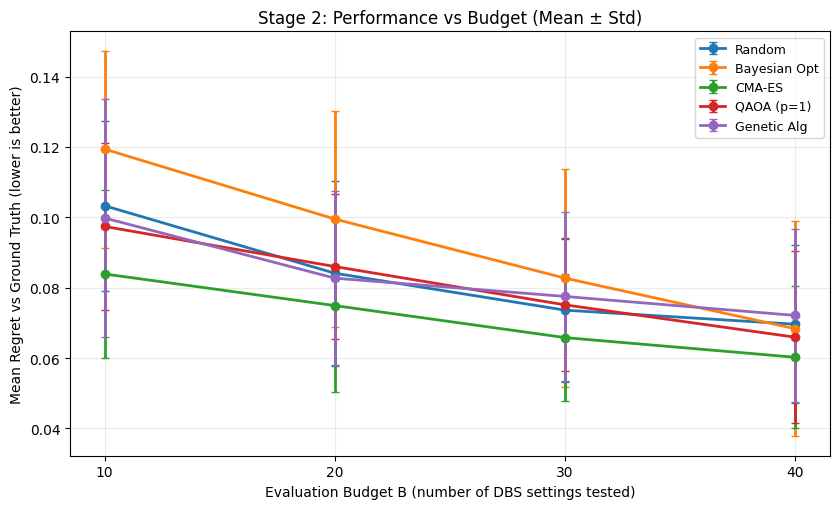

In [35]:
import numpy as np
import matplotlib.pyplot as plt

budgets = np.array([10, 20, 30, 40], dtype=int)

# Only plotting the key methods (cleaner for a board)
plot_methods = {
    "Random": {
        "mean": np.array([0.1033, 0.0841, 0.0736, 0.0696]),
        "std":  np.array([0.0242, 0.0263, 0.0205, 0.0224]),
    },
    "Bayesian Opt": {
        "mean": np.array([0.1194, 0.0995, 0.0827, 0.0683]),
        "std":  np.array([0.0280, 0.0306, 0.0310, 0.0306]),
    },
    "CMA-ES": {
        "mean": np.array([0.0839, 0.0749, 0.0658, 0.0602]),
        "std":  np.array([0.0240, 0.0246, 0.0181, 0.0202]),
    },
    "QAOA (p=1)": {
        "mean": np.array([0.0974, 0.0860, 0.0751, 0.0659]),
        "std":  np.array([0.0237, 0.0205, 0.0188, 0.0244]),
    },
    "Genetic Alg": {
        "mean": np.array([0.0998, 0.0827, 0.0775, 0.0721]),
        "std":  np.array([0.0339, 0.0248, 0.0240, 0.0245]),
    },
}

plt.figure(figsize=(8.5, 5.2))

for name, d in plot_methods.items():
    plt.errorbar(
        budgets,
        d["mean"],
        yerr=d["std"],
        marker="o",
        capsize=3,
        linewidth=2,
        label=name
    )

plt.xticks(budgets)
plt.xlabel("Evaluation Budget B (number of DBS settings tested)")
plt.ylabel("Mean Regret vs Ground Truth (lower is better)")
plt.title("Stage 2: Performance vs Budget (Mean ± Std)")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
